In [1]:
from _Aplha_n_methods import Alpha_N_calc as an
from _Aplha_n_methods import init_worker
from _Geometry_methods import Geometry_helper as gh
from _Prettyplt import PrettyPlot as pp

import openmc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import os


import openmc.deplete as dep
import time
from collections import defaultdict #To use dictionaries to remove dublicates

os.system("rm model.xml")

rm: cannot remove 'model.xml': No such file or directory


256

In [2]:
#Setting geometry and materials
#Geometry
new_geom = True
fuel_name="Fuel_CA_2"


if new_geom:
    inner_fuel_r = 35
    outer_fuel_r = 75
    outer_moderater_r = 80
    
    with_blanket = True
    blanket_or = 100
    
    inner_moderator_height = 25
    geom, materials= gh.set_geom_fuel_shell(inner_fuel_r,outer_fuel_r,outer_moderater_r,with_blanket=with_blanket,
                               blanket_or=blanket_or, inner_moderator_height=inner_moderator_height, fuel_name=fuel_name)
else:
    openmc.reset_auto_ids()
    geom = openmc.Geometry.from_xml("geometry.xml")
    materials= openmc.Materials.from_xml('materials.xml')
fuel = gh.get_material_by_name(fuel_name,materials)


Fuel_CA_1
Fuel_CA_2
Blanket_CA
Fuel_A
Fuel_B
Fuel_C
Air
h2o
d2o
uo2


/openmc_venv/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Cell instance already exists with id=1.
  warn(msg, IDWarning)


1e-50
len target elements 6, #elements 6
SRModule done
Making kernels and integrent...
setup done in 0.36438807200465817 s
n_per_s_per_kg:  179.709274707984


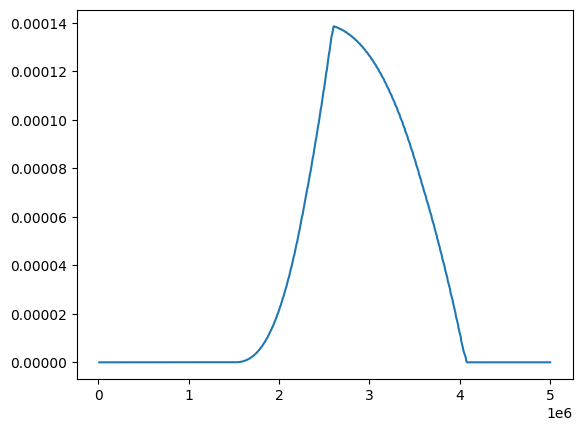

In [3]:
neutron_intensities,neutron_energies,n_per_s_per_kg = an.neutron_spectra_from_material(fuel,E_min=1e4,nr_points=1000,nr_energies=1000,new_file=False)
neutron_intensities = np.clip(neutron_intensities,0,None)
energy = openmc.stats.Tabular(neutron_energies, neutron_intensities)

fig,ax =plt.subplots()

ax.plot(neutron_energies,neutron_intensities)

print('n_per_s_per_kg: ',n_per_s_per_kg)

In [4]:
def shell_vol_calc(geom_or,geom_ir):
    volume=4/3*np.pi*(geom_or**3-geom_ir**3)
    return volume

fuel_vol = shell_vol_calc(outer_fuel_r,inner_fuel_r)
fuel_mass = fuel.density*fuel_vol/1000 #g/cm^3*cm^3 -> kg

fuel.volume = fuel_vol

print('fuel_mass',fuel_mass)

total_n_per_s = n_per_s_per_kg*fuel_mass

print('total n production',total_n_per_s)

fuel_mass 7786.940046746876
total n production 1399385.347995436


In [5]:
inner_fuel_radius = geom.get_surfaces_by_name('fuel_inner')[0].bounding_box('-')[1][0]
outer_fuel_radius = geom.get_surfaces_by_name('fuel_outer')[0].bounding_box('-')[1][0]

fuel_space = openmc.stats.spherical_uniform(r_outer=outer_fuel_radius,r_inner=inner_fuel_radius)

In [6]:
settings_dep = openmc.Settings()
settings_dep.run_mode =  'fixed source'

#Fixing Li6 at 900 K doesn't have a cross section 
settings_dep.temperature = {
    'method': 'nearest',
    'tolerance': 1000}

settings_dep.batches = 3
settings_dep.inactive = 0
#settings_dep.particles = 2000 

#model_dep = openmc.Model(geometry=geom, materials=materials, settings=settings_dep)
def openmcRunDepletion(geom, settings, materials,timestep_units):
    chain_file="chain_endfb71_sfr.xml"
    # Depletion operator
    print('nr of batches',settings.batches,' particles ',settings.particles)
    model_dep = openmc.Model(geometry=geom, materials=materials, settings=settings)
    model_dep.export_to_xml()
    op = dep.CoupledOperator(model_dep,chain_file)
    
    # Take one timestep
    timestep = [1]  # days also only test
    power = 1e6 # watts Needs to be changed, can be excluded?
    
    # Deplete using mid-point predictor-corrector
    cecm = openmc.deplete.CECMIntegrator(
        op, timestep, power, timestep_units=timestep_units)
    cecm.integrate() 

In [7]:
def openmcRunDepletionFast(geom, settings, materials,timestep_units):
    chain_file="chain_endfb71_sfr.xml"
    # Depletion operator
    print('nr of batches',settings.batches,' particles ',settings.particles)
    model_dep = openmc.Model(geometry=geom, materials=materials, settings=settings)
    model_dep.export_to_xml()
    op = dep.CoupledOperator(model_dep,chain_file)
    
    # Take one timestep
    timestep = [1]  # days also only test
    power = 1e6 # watts Needs to be changed, can be excluded?
    
    # Deplete using mid-point predictor-corrector
    pInt = openmc.deplete.PredictorIntegrator(
        op, timestep, power, timestep_units=timestep_units)
    pInt.integrate() 

In [8]:
timestep_units = 'h'
cells = list(geom.get_all_cells().values())
#for cell in cells:
    #print(cell)
nr_steps = 3
start_i = time.perf_counter()
timesteps_fast = np.zeros(nr_steps)
fuel = gh.get_material_by_name(fuel_name,materials)

print(settings_dep.batches)

for step in range(nr_steps):
    #Filling cell with fuel
    fuel_cell = geom.get_all_cells()[1]
    fuel_cell.fill = fuel

    if fuel.density != None:
        fuel_mass = fuel.density*fuel_vol/1000 #g/cm^3*cm^3 -> kg
        fuel_density = fuel.density
    else:
        print(f'using old density{fuel_density}')
        fuel_mass = fuel_density*fuel_vol/1000
        fuel.set_density('g/cm3', fuel_density)
    
    #Getting alpha,n and setting source
    neutron_intensities,neutron_energies,n_per_s_per_kg = an.neutron_spectra_from_material(fuel,E_min=1e4,nr_points=1000,nr_energies=1000,new_file=True)
    neutron_intensities = np.clip(neutron_intensities,0,None)
    energy = openmc.stats.Tabular(neutron_energies, neutron_intensities)
    
    fuel_vol = shell_vol_calc(outer_fuel_r,inner_fuel_r)
    
    
    
    total_n_per_s = n_per_s_per_kg*fuel_mass
    
    src = openmc.IndependentSource(space=fuel_space, energy=energy,particle='neutron', strength=total_n_per_s)

    settings_dep.particles = 1000
    settings_dep.source = [src]
    
    openmcRunDepletionFast(geom, settings_dep, materials,timestep_units=timestep_units)

    timesteps_fast[step] = time.perf_counter()-start_i

    print(f'timesteps {timesteps_fast[step]/60} min, particles: {settings_dep.particles}, batches: {settings_dep.batches}')
    
    results = openmc.deplete.Results("depletion_results.h5")
    
    materials = results.export_to_materials(burnup_index=1)
    materials.export_to_xml(f"{fuel_name}_{step}_{timestep_units}_fast.xml")
    
    fuel = gh.get_material_by_name(fuel_name,materials)
    #for mat in materials:
        #print(mat.id, mat.name)

3
1e-50
len target elements 6, #elements 6
Waiting for SRModule to produce output...
SRModule done
Making kernels and integrent...
setup done in 1.3191782790017896 s
nr of batches 3  particles  1000
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                #############

 Reading Na22 from /root/nndc_hdf5/Na22.h5
 Reading Na23 from /root/nndc_hdf5/Na23.h5
 Reading Mg24 from /root/nndc_hdf5/Mg24.h5
 Reading Mg25 from /root/nndc_hdf5/Mg25.h5
 Reading Mg26 from /root/nndc_hdf5/Mg26.h5
 Reading Al27 from /root/nndc_hdf5/Al27.h5
 Reading Si28 from /root/nndc_hdf5/Si28.h5
 Reading Si29 from /root/nndc_hdf5/Si29.h5
 Reading Si30 from /root/nndc_hdf5/Si30.h5
 Reading P31 from /root/nndc_hdf5/P31.h5
 Reading S32 from /root/nndc_hdf5/S32.h5
 Reading S33 from /root/nndc_hdf5/S33.h5
 Reading S34 from /root/nndc_hdf5/S34.h5
 Reading S36 from /root/nndc_hdf5/S36.h5
 Reading Cl35 from /root/nndc_hdf5/Cl35.h5
 Reading Cl37 from /root/nndc_hdf5/Cl37.h5
 Reading K39 from /root/nndc_hdf5/K39.h5
 Reading K40 from /root/nndc_hdf5/K40.h5
 Reading K41 from /root/nndc_hdf5/K41.h5
 Reading Ca40 from /root/nndc_hdf5/Ca40.h5
 Reading Ca42 from /root/nndc_hdf5/Ca42.h5
 Reading Ca43 from /root/nndc_hdf5/Ca43.h5
 Reading Ca44 from /root/nndc_hdf5/Ca44.h5
 Reading Ca46 from /root/nn

 Reading Kr80 from /root/nndc_hdf5/Kr80.h5
 Reading Kr82 from /root/nndc_hdf5/Kr82.h5
 Reading Kr83 from /root/nndc_hdf5/Kr83.h5
 Reading Kr84 from /root/nndc_hdf5/Kr84.h5
 Reading Kr85 from /root/nndc_hdf5/Kr85.h5
 Reading Kr86 from /root/nndc_hdf5/Kr86.h5
 Reading Rb85 from /root/nndc_hdf5/Rb85.h5
 Reading Rb86 from /root/nndc_hdf5/Rb86.h5
 Reading Rb87 from /root/nndc_hdf5/Rb87.h5
 Reading Sr84 from /root/nndc_hdf5/Sr84.h5
 Reading Sr86 from /root/nndc_hdf5/Sr86.h5
 Reading Sr87 from /root/nndc_hdf5/Sr87.h5
 Reading Sr88 from /root/nndc_hdf5/Sr88.h5
 Reading Sr89 from /root/nndc_hdf5/Sr89.h5
 Reading Sr90 from /root/nndc_hdf5/Sr90.h5
 Reading Y89 from /root/nndc_hdf5/Y89.h5
 Reading Y90 from /root/nndc_hdf5/Y90.h5
 Reading Y91 from /root/nndc_hdf5/Y91.h5
 Reading Zr93 from /root/nndc_hdf5/Zr93.h5
 Reading Zr95 from /root/nndc_hdf5/Zr95.h5
 Reading Nb93 from /root/nndc_hdf5/Nb93.h5
 Reading Nb94 from /root/nndc_hdf5/Nb94.h5
 Reading Nb95 from /root/nndc_hdf5/Nb95.h5
 Reading Mo92 fro

 Reading Mo96 from /root/nndc_hdf5/Mo96.h5
 Reading Mo97 from /root/nndc_hdf5/Mo97.h5
 Reading Mo98 from /root/nndc_hdf5/Mo98.h5
 Reading Mo99 from /root/nndc_hdf5/Mo99.h5
 Reading Mo100 from /root/nndc_hdf5/Mo100.h5
 Reading Tc99 from /root/nndc_hdf5/Tc99.h5
 Reading Ru96 from /root/nndc_hdf5/Ru96.h5
 Reading Ru98 from /root/nndc_hdf5/Ru98.h5
 Reading Ru99 from /root/nndc_hdf5/Ru99.h5


 Reading Ru100 from /root/nndc_hdf5/Ru100.h5
 Reading Ru101 from /root/nndc_hdf5/Ru101.h5
 Reading Ru102 from /root/nndc_hdf5/Ru102.h5
 Reading Ru103 from /root/nndc_hdf5/Ru103.h5
 Reading Ru104 from /root/nndc_hdf5/Ru104.h5
 Reading Ru105 from /root/nndc_hdf5/Ru105.h5
 Reading Ru106 from /root/nndc_hdf5/Ru106.h5
 Reading Rh103 from /root/nndc_hdf5/Rh103.h5
 Reading Rh105 from /root/nndc_hdf5/Rh105.h5
 Reading Pd102 from /root/nndc_hdf5/Pd102.h5
 Reading Pd104 from /root/nndc_hdf5/Pd104.h5
 Reading Pd105 from /root/nndc_hdf5/Pd105.h5
 Reading Pd106 from /root/nndc_hdf5/Pd106.h5
 Reading Pd107 from /root/nndc_hdf5/Pd107.h5
 Reading Pd108 from /root/nndc_hdf5/Pd108.h5
 Reading Pd110 from /root/nndc_hdf5/Pd110.h5
 Reading Ag107 from /root/nndc_hdf5/Ag107.h5
 Reading Ag109 from /root/nndc_hdf5/Ag109.h5
 Reading Ag110_m1 from /root/nndc_hdf5/Ag110_m1.h5
 Reading Ag111 from /root/nndc_hdf5/Ag111.h5
 Reading Cd106 from /root/nndc_hdf5/Cd106.h5
 Reading Cd108 from /root/nndc_hdf5/Cd108.h5
 Rea

...

 Reading Cd116 from /root/nndc_hdf5/Cd116.h5
 Reading In113 from /root/nndc_hdf5/In113.h5
 Reading In115 from /root/nndc_hdf5/In115.h5
 Reading Sn112 from /root/nndc_hdf5/Sn112.h5
 Reading Sn113 from /root/nndc_hdf5/Sn113.h5
 Reading Sn114 from /root/nndc_hdf5/Sn114.h5
 Reading Sn115 from /root/nndc_hdf5/Sn115.h5
 Reading Sn116 from /root/nndc_hdf5/Sn116.h5
 Reading Sn117 from /root/nndc_hdf5/Sn117.h5
 Reading Sn118 from /root/nndc_hdf5/Sn118.h5
 Reading Sn119 from /root/nndc_hdf5/Sn119.h5
 Reading Sn120 from /root/nndc_hdf5/Sn120.h5
 Reading Sn122 from /root/nndc_hdf5/Sn122.h5
 Reading Sn123 from /root/nndc_hdf5/Sn123.h5
 Reading Sn124 from /root/nndc_hdf5/Sn124.h5
 Reading Sn125 from /root/nndc_hdf5/Sn125.h5
 Reading Sn126 from /root/nndc_hdf5/Sn126.h5
 Reading Sb121 from /root/nndc_hdf5/Sb121.h5
 Reading Sb123 from /root/nndc_hdf5/Sb123.h5
 Reading Sb124 from /root/nndc_hdf5/Sb124.h5
 Reading Sb125 from /root/nndc_hdf5/Sb125.h5
 Reading Sb126 from /root/nndc_hdf5/Sb126.h5
 Reading T

 Reading Te123 from /root/nndc_hdf5/Te123.h5
 Reading Te124 from /root/nndc_hdf5/Te124.h5
 Reading Te125 from /root/nndc_hdf5/Te125.h5
 Reading Te126 from /root/nndc_hdf5/Te126.h5
 Reading Te127_m1 from /root/nndc_hdf5/Te127_m1.h5
 Reading Te128 from /root/nndc_hdf5/Te128.h5
 Reading Te129_m1 from /root/nndc_hdf5/Te129_m1.h5
 Reading Te130 from /root/nndc_hdf5/Te130.h5
 Reading Te132 from /root/nndc_hdf5/Te132.h5
 Reading I127 from /root/nndc_hdf5/I127.h5
 Reading I129 from /root/nndc_hdf5/I129.h5
 Reading I130 from /root/nndc_hdf5/I130.h5
 Reading I131 from /root/nndc_hdf5/I131.h5


 Reading I135 from /root/nndc_hdf5/I135.h5
 Reading Xe126 from /root/nndc_hdf5/Xe126.h5
 Reading Xe128 from /root/nndc_hdf5/Xe128.h5
 Reading Xe129 from /root/nndc_hdf5/Xe129.h5
 Reading Xe130 from /root/nndc_hdf5/Xe130.h5
 Reading Xe131 from /root/nndc_hdf5/Xe131.h5
 Reading Xe132 from /root/nndc_hdf5/Xe132.h5
 Reading Xe133 from /root/nndc_hdf5/Xe133.h5
 Reading Xe134 from /root/nndc_hdf5/Xe134.h5
 Reading Xe135 from /root/nndc_hdf5/Xe135.h5
 Reading Xe136 from /root/nndc_hdf5/Xe136.h5
 Reading Cs133 from /root/nndc_hdf5/Cs133.h5
 Reading Cs134 from /root/nndc_hdf5/Cs134.h5
 Reading Cs135 from /root/nndc_hdf5/Cs135.h5
 Reading Cs136 from /root/nndc_hdf5/Cs136.h5
 Reading Cs137 from /root/nndc_hdf5/Cs137.h5
 Reading Ba132 from /root/nndc_hdf5/Ba132.h5
 Reading Ba133 from /root/nndc_hdf5/Ba133.h5
 Reading Ba134 from /root/nndc_hdf5/Ba134.h5
 Reading Ba135 from /root/nndc_hdf5/Ba135.h5
 Reading Ba136 from /root/nndc_hdf5/Ba136.h5
 Reading Ba137 from /root/nndc_hdf5/Ba137.h5
 Reading Ba1

 Reading Ce138 from /root/nndc_hdf5/Ce138.h5
 Reading Ce139 from /root/nndc_hdf5/Ce139.h5
 Reading Ce140 from /root/nndc_hdf5/Ce140.h5
 Reading Ce141 from /root/nndc_hdf5/Ce141.h5
 Reading Ce142 from /root/nndc_hdf5/Ce142.h5
 Reading Ce143 from /root/nndc_hdf5/Ce143.h5
 Reading Ce144 from /root/nndc_hdf5/Ce144.h5
 Reading Pr141 from /root/nndc_hdf5/Pr141.h5
 Reading Pr142 from /root/nndc_hdf5/Pr142.h5
 Reading Pr143 from /root/nndc_hdf5/Pr143.h5
 Reading Nd142 from /root/nndc_hdf5/Nd142.h5
 Reading Nd143 from /root/nndc_hdf5/Nd143.h5
 Reading Nd144 from /root/nndc_hdf5/Nd144.h5
 Reading Nd145 from /root/nndc_hdf5/Nd145.h5
 Reading Nd146 from /root/nndc_hdf5/Nd146.h5
 Reading Nd147 from /root/nndc_hdf5/Nd147.h5
 Reading Nd148 from /root/nndc_hdf5/Nd148.h5
 Reading Nd150 from /root/nndc_hdf5/Nd150.h5
 Reading Pm147 from /root/nndc_hdf5/Pm147.h5
 Reading Pm148 from /root/nndc_hdf5/Pm148.h5
 Reading Pm148_m1 from /root/nndc_hdf5/Pm148_m1.h5
 Reading Pm149 from /root/nndc_hdf5/Pm149.h5
 Rea

 Reading Gd153 from /root/nndc_hdf5/Gd153.h5
 Reading Gd154 from /root/nndc_hdf5/Gd154.h5
 Reading Gd155 from /root/nndc_hdf5/Gd155.h5
 Reading Gd156 from /root/nndc_hdf5/Gd156.h5
 Reading Gd157 from /root/nndc_hdf5/Gd157.h5
 Reading Gd158 from /root/nndc_hdf5/Gd158.h5
 Reading Gd160 from /root/nndc_hdf5/Gd160.h5
 Reading Tb159 from /root/nndc_hdf5/Tb159.h5
 Reading Tb160 from /root/nndc_hdf5/Tb160.h5
 Reading Dy156 from /root/nndc_hdf5/Dy156.h5
 Reading Dy158 from /root/nndc_hdf5/Dy158.h5
 Reading Dy160 from /root/nndc_hdf5/Dy160.h5
 Reading Dy161 from /root/nndc_hdf5/Dy161.h5
 Reading Dy162 from /root/nndc_hdf5/Dy162.h5
 Reading Dy163 from /root/nndc_hdf5/Dy163.h5
 Reading Dy164 from /root/nndc_hdf5/Dy164.h5
 Reading Ho165 from /root/nndc_hdf5/Ho165.h5
 Reading Ho166_m1 from /root/nndc_hdf5/Ho166_m1.h5
 Reading Er162 from /root/nndc_hdf5/Er162.h5
 Reading Er164 from /root/nndc_hdf5/Er164.h5
 Reading Er166 from /root/nndc_hdf5/Er166.h5
 Reading Er167 from /root/nndc_hdf5/Er167.h5
 Rea

In [9]:
fuel_name = 'Fuel_CA_2'
fuel = gh.get_material_by_name(fuel_name,materials)

for step in range(nr_steps):
    #Filling cell with fuel
    fuel_cell = geom.get_all_cells()[1]
    fuel_cell.fill = fuel
    
    #Getting alpha,n and setting source
    neutron_intensities,neutron_energies,n_per_s_per_kg = an.neutron_spectra_from_material(fuel,E_min=1e4,nr_points=1000,nr_energies=1000,new_file=False)
    neutron_intensities = np.clip(neutron_intensities,0,None)
    energy = openmc.stats.Tabular(neutron_energies, neutron_intensities)
    
    fuel_vol = shell_vol_calc(outer_fuel_r,inner_fuel_r)
    fuel_mass = fuel.density*fuel_vol/1000 #g/cm^3*cm^3 -> kg
    
    total_n_per_s = n_per_s_per_kg*fuel_mass

    settings_dep.particles = 500*(step+1)
    settings_dep.source = [src]
    
    src = openmc.IndependentSource(space=fuel_space, energy=energy,particle='neutron', strength=total_n_per_s)
    
    openmcRunDepletion(geom, settings_dep, materials,timestep_units=timestep_units)

    timesteps[step] = start_i - time.perf_counter()
    print(f'timesteps {timesteps_fast},{settings_dep.particles}')
    
    results = openmc.deplete.Results("depletion_results.h5")
    
    materials = results.export_to_materials(burnup_index=1,path=f"{fuel_name}_{step}_{timestep_units}.xml")
    fuel = get_material_by_name(fuel_name,materials)
    for materialsin materials:
        print(mat.id, mat.name)

SyntaxError: invalid syntax (3565607457.py, line 33)

In [10]:
for slow,fast in zip(timesteps_fast,timesteps_fast):
    #print(f'slow: {slow/60:.4g},\t fast:{fast/60:.4g}')
    print(f' fast:{fast/60:.4g}')

 fast:19.98
 fast:44.68
 fast:75.64


In [ ]:
'''# Load materials from XML
materials = openmc.Materials.from_xml("materials-finish.xml")

#Using fond materials 
materials = results.export_to_materials(1)
# Collect all nuclides present
nuclides = []

materials= get_material_by_name("Fuel_CA_2",materials)
for nuclide, amount,_ in mat.nuclides:
    nuclides.append([nuclide,amount])

print(nuclides)'''

In [ ]:
print(
    f"step={step}, "
    f"fuel id={fuel.id}, "
    f"name={fuel.name}, "
    f"density={fuel.density}, "
    f"density_units={fuel.density_units}"
)